In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import the libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# read the dataset
df = pd.read_csv('/content/drive/MyDrive/Retail AI Solution/Datasets/Recommendation/Market Basket Analysis/transactional_data.csv')
df.head()

,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity,ProductSubcategoryKey,ProductSKU,ProductName,ModelName,ProductDescription,ProductColor,ProductSize,ProductStyle,ProductCost,ProductPrice
0,2022-01-01 00:00:00,2021-09-21 00:00:00,SO45080,332,14657.0,1.0,1,1.0,2,BK-R50B-58,"Road-650 Black, 58",Road-650,Value-priced bike with many features of our to...,Black,58,U,413.1463,699.0982
1,2022-01-01 00:00:00,2021-12-05 00:00:00,SO45079,312,29255.0,4.0,1,1.0,2,BK-R93R-48,"Road-150 Red, 48",Road-150,This bike is ridden by race winners. Developed...,Red,48,U,2171.2942,3578.2700
2,2022-01-01 00:00:00,2021-10-29 00:00:00,SO45082,350,11455.0,9.0,1,1.0,1,BK-M82B-44,"Mountain-100 Black, 44",Mountain-100,Top-of-the-line competition mountain bike. Per...,Black,44,U,1898.0944,3374.9900
3,2022-01-01 00:00:00,2021-11-16 00:00:00,SO45081,338,26782.0,6.0,1,1.0,2,BK-R50B-44,"Road-650 Black, 44",Road-650,Value-priced bike with many features of our to...,Black,44,U,413.1463,699.0982
4,2022-01-02 00:00:00,2021-12-15 00:00:00,SO45083,312,14947.0,10.0,1,1.0,2,BK-R93R-48,"Road-150 Red, 48",Road-150,This bike is ridden by race winners. Developed...,Red,48,U,2171.2942,3578.2700


In [ ]:
df.shape

(59631, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59631 entries, 0 to 59630
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   OrderDate              59631 non-null  object 
 1   StockDate              59321 non-null  object 
 2   OrderNumber            59496 non-null  object 
 3   ProductKey             59631 non-null  int64  
 4   CustomerKey            59158 non-null  float64
 5   TerritoryKey           59381 non-null  float64
 6   OrderLineItem          59631 non-null  int64  
 7   OrderQuantity          59605 non-null  float64
 8   ProductSubcategoryKey  59631 non-null  int64  
 9   ProductSKU             59631 non-null  object 
 10  ProductName            59631 non-null  object 
 11  ModelName              59631 non-null  object 
 12  ProductDescription     59631 non-null  object 
 13  ProductColor           29869 non-null  object 
 14  ProductSize            59631 non-null  object 
 15  Pr

In [ ]:
df.isnull().sum()

,0
OrderDate,0
StockDate,310
OrderNumber,135
ProductKey,0
CustomerKey,473
TerritoryKey,250
OrderLineItem,0
OrderQuantity,26
ProductSubcategoryKey,0
ProductSKU,0


In [ ]:
df.dropna(subset='OrderNumber', inplace=True)
df.reset_index(drop=True, inplace=True)

In [ ]:
df.isnull().sum()

,0
OrderDate,0
StockDate,310
OrderNumber,0
ProductKey,0
CustomerKey,473
TerritoryKey,250
OrderLineItem,0
OrderQuantity,24
ProductSubcategoryKey,0
ProductSKU,0


In [ ]:
df.shape

(59496, 18)

In [ ]:
df.duplicated(subset='OrderNumber').sum()

np.int64(34463)

In [ ]:
# Create the Basket by grouping Book ID and Title
basket = df.groupby('OrderNumber')['ProductName'].apply(list)
basket.head()

,ProductName
OrderNumber,
SO45079,"[Road-150 Red, 48]"
SO45080,"[Road-650 Black, 58]"
SO45081,"[Road-650 Black, 44]"
SO45082,"[Mountain-100 Black, 44]"
SO45083,"[Road-150 Red, 48]"


In [ ]:
te = TransactionEncoder()
te_ary = te.fit(basket).transform(basket)
df_basket = pd.DataFrame(te_ary, columns=te.columns_)
df_basket.head()

,AWC Logo Cap,All-Purpose Bike Stand,Bike Wash - Dissolver,"Classic Vest, L","Classic Vest, M","Classic Vest, S",Fender Set - Mountain,HL Mountain Tire,HL Road Tire,"Half-Finger Gloves, L",...,"Touring-3000 Blue, 62","Touring-3000 Yellow, 44","Touring-3000 Yellow, 50","Touring-3000 Yellow, 54","Touring-3000 Yellow, 58","Touring-3000 Yellow, 62",Water Bottle - 30 oz.,"Women's Mountain Shorts, L","Women's Mountain Shorts, M","Women's Mountain Shorts, S"
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
frequent_itemsets = apriori(df_basket, min_support=0.01, use_colnames=True)
frequent_itemsets.head()

,support,itemsets
0,0.082371,(AWC Logo Cap)
1,0.033955,(Bike Wash - Dissolver)
2,0.078896,(Fender Set - Mountain)
3,0.052131,(HL Mountain Tire)
4,0.031758,(HL Road Tire)


In [ ]:
frequent_itemsets.shape

(91, 2)

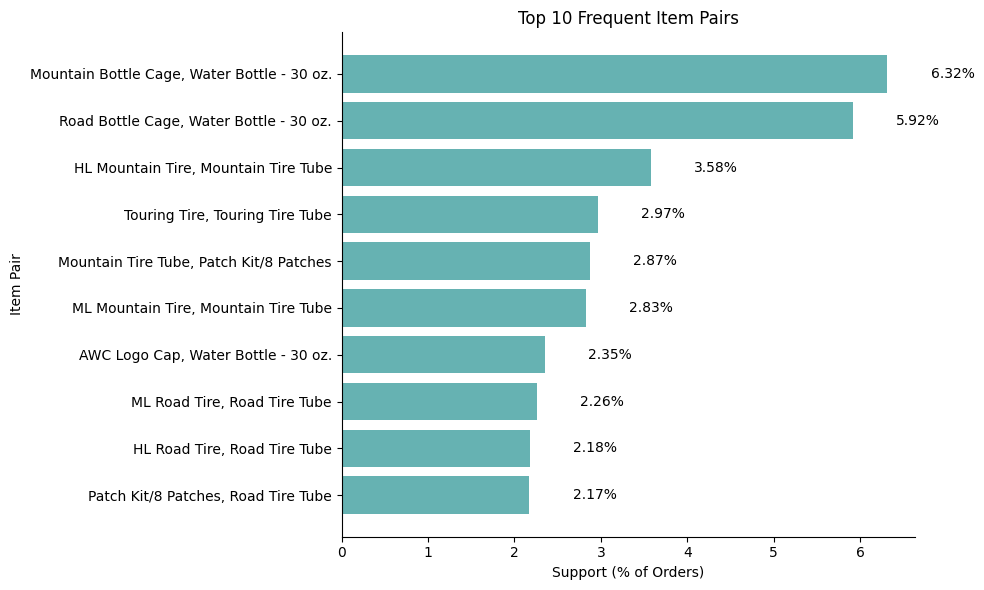

In [ ]:
# Filter more than 1-item itemsets and get top 10 by support
top_pairs = frequent_itemsets[frequent_itemsets["itemsets"].apply(lambda x: len(x) > 1)]
top_pairs = top_pairs.sort_values(by="support", ascending=False).head(10)

# Step 3: Convert itemsets to string for labeling
pairs = top_pairs["itemsets"].apply(lambda x: ', '.join(sorted(list(x))))
support_values = top_pairs["support"] * 100  # Convert to percentage

# Step 4: Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(pairs, support_values, color="#66b2b2")

# Add labels to bars
for bar, support in zip(bars, support_values):
  plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f"{support:.2f}%", va='center', ha='left', color="black", fontsize=10)

plt.xlabel('Support (% of Orders)')
plt.ylabel('Item Pair')
plt.title("Top 10 Frequent Item Pairs")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().invert_yaxis()  # Highest support at the top
plt.tight_layout()
plt.show()

In [ ]:
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(HL Mountain Tire),(Mountain Tire Tube),0.052131,0.113690,0.035753,0.685824,6.032406,1.0,0.029826,2.821060,0.880110,0.274877,0.645523,0.500150
1,(HL Road Tire),(Road Tire Tube),0.031758,0.086805,0.021811,0.686792,7.911862,1.0,0.019054,2.915621,0.902262,0.225434,0.657020,0.469029
2,(LL Mountain Tire),(Mountain Tire Tube),0.031478,0.113690,0.017697,0.562183,4.944877,1.0,0.014118,2.024384,0.823699,0.138828,0.506022,0.358920
3,(LL Road Tire),(Road Tire Tube),0.038230,0.086805,0.020014,0.523511,6.030856,1.0,0.016695,1.916507,0.867344,0.190567,0.478217,0.377034
4,(ML Mountain Tire),(Mountain Tire Tube),0.042304,0.113690,0.028283,0.668555,5.880514,1.0,0.023473,2.674081,0.866608,0.221458,0.626040,0.458663


In [ ]:
rules.shape

(12, 14)

In [ ]:
rules.sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
8,(Touring Tire),(Touring Tire Tube),0.034474,0.054488,0.029681,0.860950,15.800708,1.0,0.027802,6.799807,0.970157,0.500674,0.852937,0.702836
9,(Touring Tire Tube),(Touring Tire),0.054488,0.034474,0.029681,0.544721,15.800708,1.0,0.027802,2.120736,0.990693,0.500674,0.528465,0.702836
11,"(Water Bottle - 30 oz., Fender Set - Mountain)",(Mountain Bottle Cage),0.011824,0.075740,0.011824,1.000000,13.203059,1.0,0.010929,inf,0.935320,0.156118,1.000000,0.578059
1,(HL Road Tire),(Road Tire Tube),0.031758,0.086805,0.021811,0.686792,7.911862,1.0,0.019054,2.915621,0.902262,0.225434,0.657020,0.469029
5,(ML Road Tire),(Road Tire Tube),0.034674,0.086805,0.022610,0.652074,7.511901,1.0,0.019600,2.624678,0.898016,0.228687,0.619001,0.456272
0,(HL Mountain Tire),(Mountain Tire Tube),0.052131,0.113690,0.035753,0.685824,6.032406,1.0,0.029826,2.821060,0.880110,0.274877,0.645523,0.500150
3,(LL Road Tire),(Road Tire Tube),0.038230,0.086805,0.020014,0.523511,6.030856,1.0,0.016695,1.916507,0.867344,0.190567,0.478217,0.377034
4,(ML Mountain Tire),(Mountain Tire Tube),0.042304,0.113690,0.028283,0.668555,5.880514,1.0,0.023473,2.674081,0.866608,0.221458,0.626040,0.458663
7,(Road Bottle Cage),(Water Bottle - 30 oz.),0.066632,0.159110,0.059162,0.887890,5.580352,1.0,0.048560,7.500559,0.879396,0.355156,0.866677,0.629860
6,(Mountain Bottle Cage),(Water Bottle - 30 oz.),0.075740,0.159110,0.063157,0.833861,5.240782,1.0,0.051106,5.061357,0.875499,0.367846,0.802425,0.615399


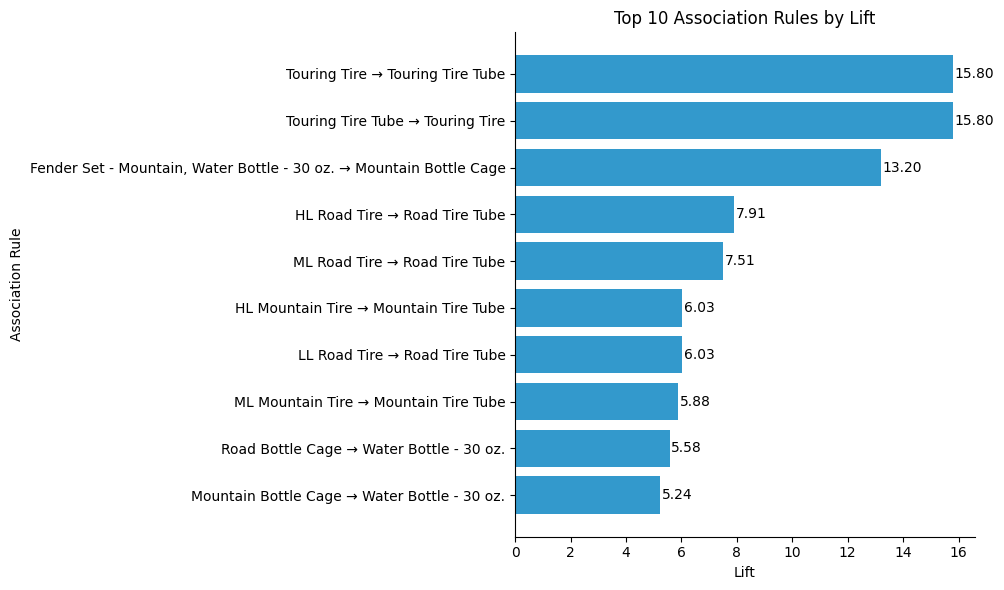

In [ ]:
# Get top 10 rules by lift
top_rules = rules.sort_values(by="lift", ascending=False).head(10)

# Step 3: Create readable labels for rule pairs (antecedent → consequent)
pairs = top_rules.apply(lambda row: f"{', '.join(sorted(row['antecedents']))} → {', '.join(sorted(row['consequents']))}", axis=1)

# Step 4: Extract lift values
lift_values = top_rules["lift"]

# Step 5: Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(pairs, lift_values, color="#3399cc")

# Add text labels to bars
for bar, lift in zip(bars, lift_values):
  plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2, f"{lift:.2f}", va='center', ha='left', color="black", fontsize=10)

# Final formatting
plt.xlabel('Lift')
plt.ylabel('Association Rule')
plt.title('Top 10 Association Rules by Lift')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().invert_yaxis()  # Highest lift at top
plt.tight_layout()
plt.show()

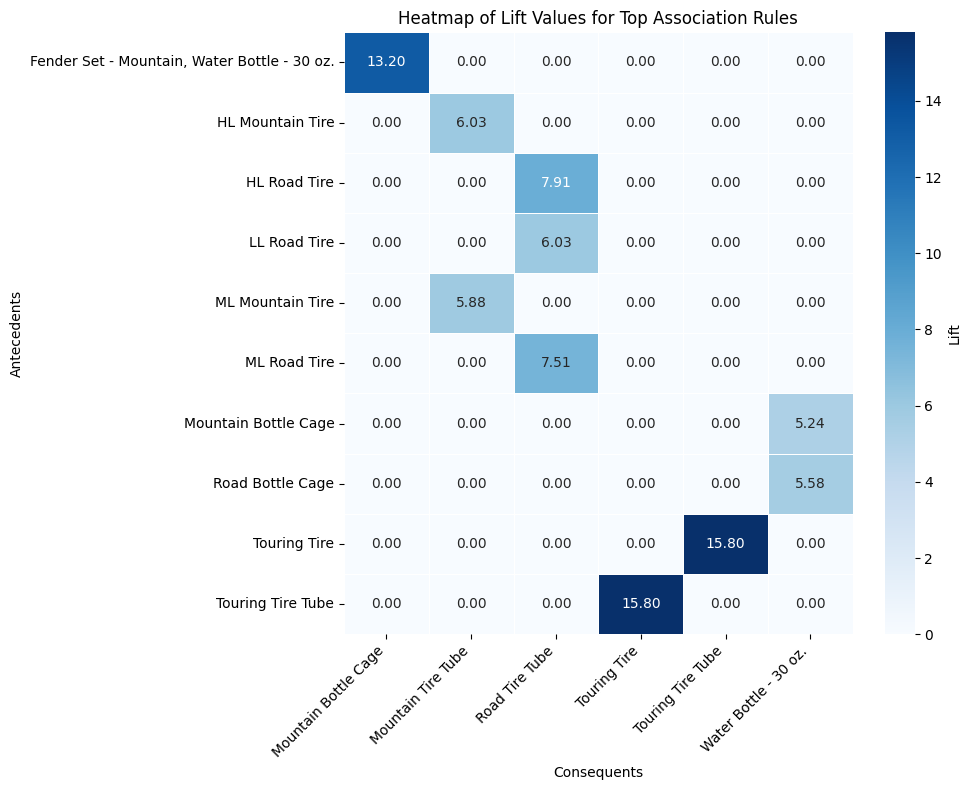

In [ ]:
# Convert frozensets to strings for better handling
top_rules['antecedents_str'] = top_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
top_rules['consequents_str'] = top_rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

# Create heatmap data using string columns
heatmap_data = pd.crosstab(
    top_rules['antecedents_str'],
    top_rules['consequents_str'],
    values=top_rules['lift'],
    aggfunc='mean'
)

heatmap_data = heatmap_data.fillna(0)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='Blues',
    cbar_kws={'label': 'Lift'},
    fmt='.2f',
    linewidths=0.5
)
plt.title('Heatmap of Lift Values for Top Association Rules')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Consequents')
plt.ylabel('Antecedents')
plt.tight_layout()
plt.show()
